In [ ]:
!pip install pandas numpy nltk sastrawi gensim wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.7 MB/s eta 0:00:00


In [ ]:
# Import manipulasi data dan regex
import pandas as pd
import numpy as np
import re

# Import library NLP
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Import representasi teks & perhitungan kemiripan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# Import visualisasi dan pengurangan dimensi
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.decomposition import PCA

# Load Dataset (Dibatasi 500 baris)
df = pd.read_csv('komdigi_hoaks.csv', nrows=500)

print(f"Memuat dataset dengan {len(df)} dokumen.")
df.head(2)

Memuat dataset dengan 500 dokumen.


,id,url,title,slug,published_at,view_count,excerpt,body_html,body_text,main_image_url,category,tags,topics
0,63682,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Anies Baswedan Beri Bantuan Modal Usah...,hoaks-anies-baswedan-beri-bantuan-modal-usaha-...,2026-04-16 23:25:00,13,NaN,"<p style=""margin-left:0in;text-align:justify;""...",Penjelasan: Beredar unggahan video yang menamp...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks
1,63681,https://www.komdigi.go.id/berita/berita-hoaks/...,[HOAKS] Tautan Rekrutmen Pertamina Periode Apr...,hoaks-tautan-rekrutmen-pertamina-periode-april...,2026-04-16 23:20:00,11,NaN,"<p style=""margin-left:0in;text-align:justify;""...",Penjelasan: Beredar di media sosial Facebook i...,https://web.komdigi.go.id/resource/dXBsb2Fkcy8...,Klarifikasi Hoaks,hoaks hari ini,Hoaks


In [ ]:
print("Menyiapkan modul NLP Sastrawi...")
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
stemmer = StemmerFactory().create_stemmer()

def full_preprocess(text):
    # Cleaning
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Stopword Removal
    text = stopword_remover.remove(text)

    # Stemming
    text = stemmer.stem(text)
    return text

print("Memulai Preprocessing untuk 500 dokumen... ")
df['stemmed_text'] = df['body_text'].apply(full_preprocess)

# Token (Menggunakan .split() bawaan agar lebih stabil dan cepat)
df['tokens'] = df['stemmed_text'].apply(lambda x: x.split())

print("Preprocessing Selesai!")
df[['body_text', 'stemmed_text', 'tokens']].head(3)

Menyiapkan modul NLP Sastrawi...
Memulai Preprocessing untuk 500 dokumen... 
Preprocessing Selesai!


,body_text,stemmed_text,tokens
0,Penjelasan: Beredar unggahan video yang menamp...,jelas edar unggah video tampil mantan gubernur...,"[jelas, edar, unggah, video, tampil, mantan, g..."
1,Penjelasan: Beredar di media sosial Facebook i...,jelas edar media sosial facebook informasi tau...,"[jelas, edar, media, sosial, facebook, informa..."
2,Penjelasan: Beredar sebuah unggahan di media s...,jelas edar buah unggah media sosial facebook k...,"[jelas, edar, buah, unggah, media, sosial, fac..."


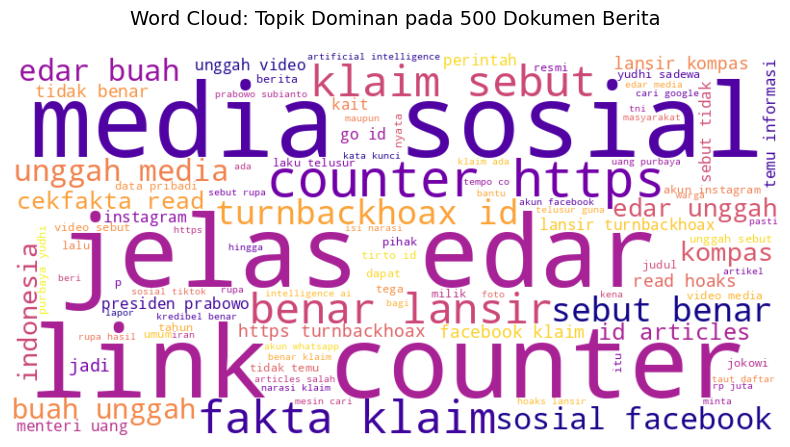

In [ ]:
# Menggabungkan text hasil steming
all_text = ' '.join(df['stemmed_text'])

# Membuat objek WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='plasma',
                      max_words=100).generate(all_text)

# Menampilkan visual
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Topik Dominan pada 500 Dokumen Berita', fontsize=14, pad=20)
plt.show()

In [ ]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['stemmed_text'])
print(f"Dimensi Matriks TF-IDF: {tfidf_matrix.shape}")

# WORD2VEC
# Train Word2Vec
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=2, workers=4)

# Vektor dokumen
def get_document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Apply ke semua dokumen
w2v_matrix = np.array([get_document_vector(tokens, w2v_model) for tokens in df['tokens']])
print(f"Dimensi Matriks Word2Vec: {w2v_matrix.shape}")

Dimensi Matriks TF-IDF: (500, 4640)
Dimensi Matriks Word2Vec: (500, 100)


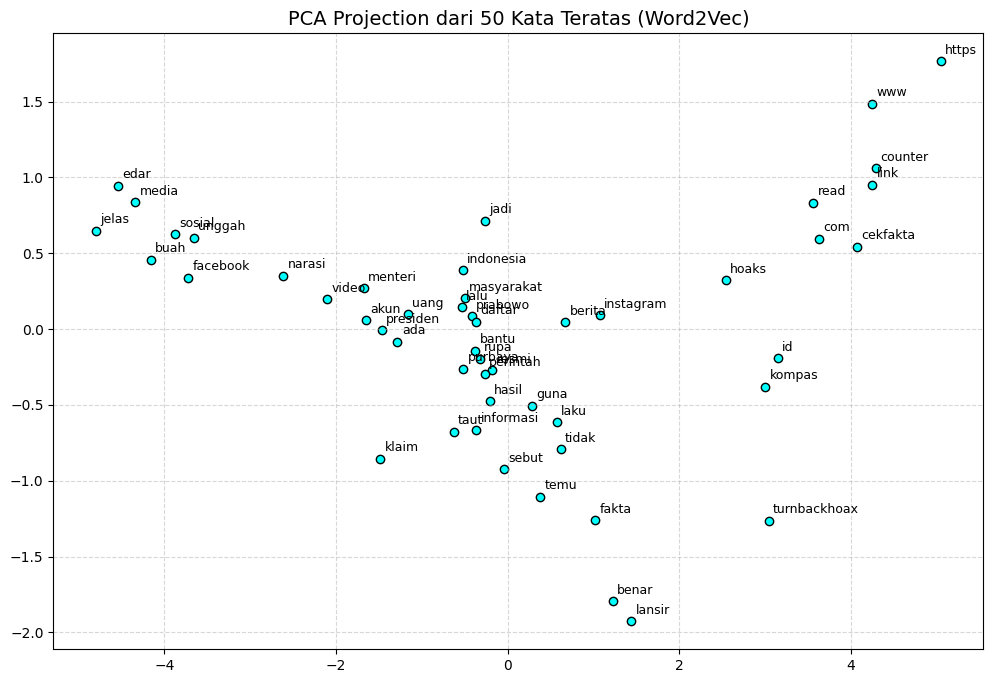

In [ ]:
# Mengambil 50 kata pertama dari kamus model Word2Vec
words_to_visualize = list(w2v_model.wv.index_to_key)[:50]
word_vectors = np.array([w2v_model.wv[word] for word in words_to_visualize])

# Mengurangi dimensi dari 100 menjadi 2 menggunakan PCA
pca = PCA(n_components=2)
twodim_pca = pca.fit_transform(word_vectors)

# Membuat Scatter Plot
plt.figure(figsize=(12, 8))
plt.scatter(twodim_pca[:, 0], twodim_pca[:, 1], edgecolors='k', c='cyan')

# Menambahkan label teks pada setiap titik
for word, (x, y) in zip(words_to_visualize, twodim_pca):
    plt.text(x + 0.05, y + 0.05, word, fontsize=9)

plt.title('PCA Projection dari 50 Kata Teratas (Word2Vec)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
def search_documents(query, method='tfidf', top_n=3):
    print(f"\n[{method.upper()}] Hasil Pencarian untuk: '{query}'")
    print("-" * 50)

    # Preprocessing pada query
    clean_query = full_preprocess(query)

    # Vektorisasi & Hitung Similarity
    if method == 'tfidf':
        query_vec = tfidf_vectorizer.transform([clean_query])
        similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

    elif method == 'word2vec':
        query_tokens = clean_query.split()
        query_vec = get_document_vector(query_tokens, w2v_model).reshape(1, -1)
        similarities = cosine_similarity(query_vec, w2v_matrix).flatten()

    else:
        return "Metode tidak valid."

    # Ambil Top-N Dokumen
    top_indices = similarities.argsort()[-top_n:][::-1]

    for i, idx in enumerate(top_indices):
        score = similarities[idx]
        if score > 0:
            print(f"Peringkat {i+1} | Skor Similarity: {score:.4f}")
            # Menampilkan 200 karakter
            print(f"Teks: {df['body_text'].iloc[idx][:200]}...\n")
        else:
            print(f"Peringkat {i+1} | Tidak ada dokumen relevan (Skor 0)")

In [ ]:
# Ganti query yang relevan dengan pencarian pribadi
test_query = "bencana alam banjir dan tanah longsor"

# Mencari dengan kedua metode untuk perbandingan
search_documents(test_query, method='tfidf', top_n=2)
search_documents(test_query, method='word2vec', top_n=2)


[TFIDF] Hasil Pencarian untuk: 'bencana alam banjir dan tanah longsor'
--------------------------------------------------
Peringkat 1 | Skor Similarity: 0.4882
Teks: Penjelasan: Beredar unggahan foto di media sosial Facebook yang mengeklaim adanya bencana tanah longsor yang terjadi mendadak. Namun dalam foto itu tidak disertai dengan keterangan lokasi dan waktu ke...

Peringkat 2 | Skor Similarity: 0.2936
Teks: Penjelasan: Beredar unggahan di media sosial Facebook yang mengeklaim bahwa Presiden Prabowo Subianto dan Ketua DPR RI Puan Maharani disebut telah sepakat menyerahkan pengelolaan tanah bekas bencana a...


[WORD2VEC] Hasil Pencarian untuk: 'bencana alam banjir dan tanah longsor'
--------------------------------------------------
Peringkat 1 | Skor Similarity: 0.9976
Teks: Penjelasan: Beredar akun WhatsApp yang mengatasnamakan Kepala Kepolisian Resort (Kapolres) Bombana AKBP Eko Sutomo, S.I.K., M.I.K. Akun tersebut menggunakan foto profil Eko Sutomo dan nomor +62 821-15...

Peri